# SUPPORT2 data exploration

SUPPORT2 follows seriously ill hospitalised adults and records demographic,
diagnostic, physiological, laboratory, functional-status, and outcome
information. This notebook establishes the population, data quality, and
hospital-exit patterns relevant to prediction after the third SUPPORT study day.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.data import create_fixed_split, load_support2

plt.style.use('seaborn-v0_8-whitegrid')
FIGURES = PROJECT_ROOT / 'results' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

## Data source and development design

The official SUPPORT2 data are retrieved through the UCI repository API.
Descriptive names replace abbreviated source names, with definitions in the
data dictionary. A fixed 70/15/15 patient split assigns distinct roles to
training, validation, and held-out test data. Exploration uses training data only.

In [2]:
df = load_support2()
train_df, validation_df, test_df = create_fixed_split(df)
display(pd.DataFrame(
    {'Patients': [len(train_df), len(validation_df), len(test_df)]},
    index=['Training', 'Validation', 'Held-out test'],
))

,Patients
Training,6373
Validation,1366
Held-out test,1366


## Missingness

Complete-case deletion could remove a large and clinically non-random part of
this cohort. Missingness is therefore described before modelling and handled
by transformations fitted only within training data.

,Missing (%)
adl_patient_reported,62.3
urine_output,53.6
glucose,49.7
blood_urea_nitrogen,48.1
total_micro_cost,38.1
albumin,36.8
income_category,32.7
adl_surrogate_reported,31.4
bilirubin,28.5
pao2_fio2_ratio,25.5


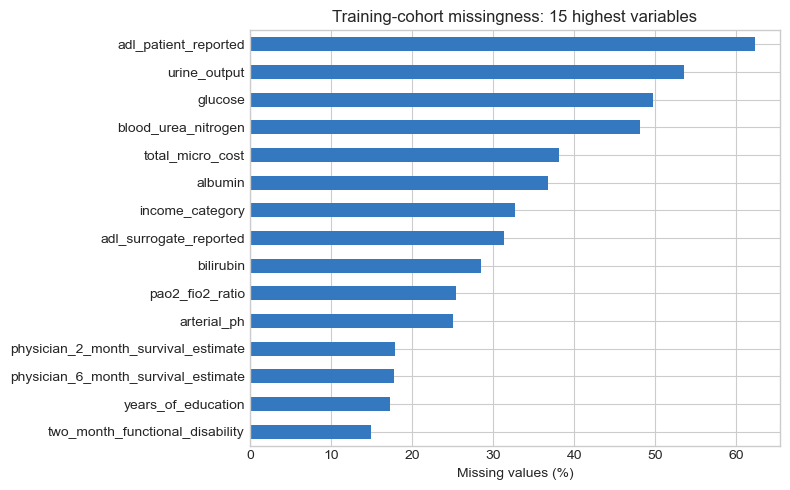

In [3]:
missingness = train_df.isna().mean().mul(100).sort_values(ascending=False)
display(missingness.head(15).rename('Missing (%)').to_frame().round(1))

fig, ax = plt.subplots(figsize=(8, 5))
missingness.head(15).sort_values().plot.barh(ax=ax, color='#3478bf')
ax.set(xlabel='Missing values (%)', ylabel='',
       title='Training-cohort missingness: 15 highest variables')
fig.tight_layout()
fig.savefig(FIGURES / 'training_missingness.png', dpi=160, bbox_inches='tight')
plt.show()

Patient-reported ADL, urine output, glucose, and blood urea nitrogen contain
substantial missingness. Retaining incomplete patients is therefore essential.

## Population and hospital-exit timing

Age and diagnosis describe case-mix heterogeneity. Exit time must be considered
with exit type because live discharge and in-hospital death have different meanings.

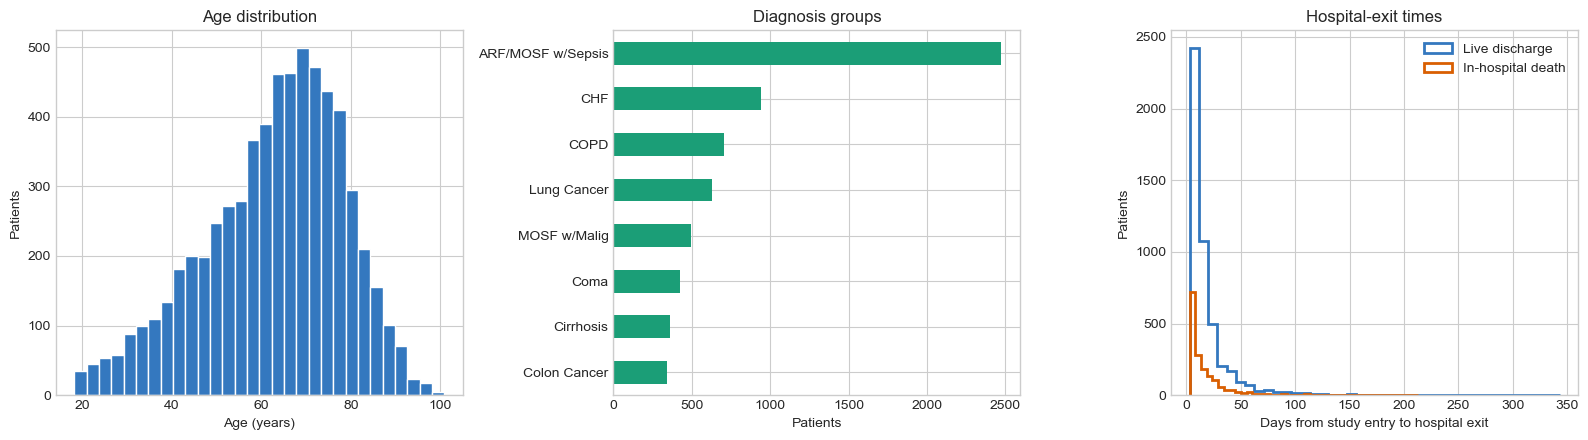

In [4]:
exit_label = np.where(
    train_df['in_hospital_death'].eq(1), 'In-hospital death', 'Live discharge'
)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(train_df['age'].dropna(), bins=30, color='#3478bf', edgecolor='white')
axes[0].set(xlabel='Age (years)', ylabel='Patients', title='Age distribution')
train_df['diagnosis_group'].value_counts().sort_values().plot.barh(
    ax=axes[1], color='#1b9e77'
)
axes[1].set(xlabel='Patients', ylabel='', title='Diagnosis groups')
for label, colour in [('Live discharge', '#3478bf'), ('In-hospital death', '#d95f02')]:
    axes[2].hist(
        train_df.loc[exit_label == label, 'days_to_hospital_exit'],
        bins=40, histtype='step', linewidth=2, color=colour, label=label,
    )
axes[2].set(xlabel='Days from study entry to hospital exit',
            ylabel='Patients', title='Hospital-exit times')
axes[2].legend()
fig.tight_layout()
fig.savefig(FIGURES / 'data_overview.png', dpi=160, bbox_inches='tight')
plt.show()

The training cohort contains broad diagnostic and age variation. Hospital-exit
time is strongly right-skewed, and the two terminal events occur across
overlapping times. These observations support patient-specific competing-event
prediction rather than regression on a single length-of-stay value.